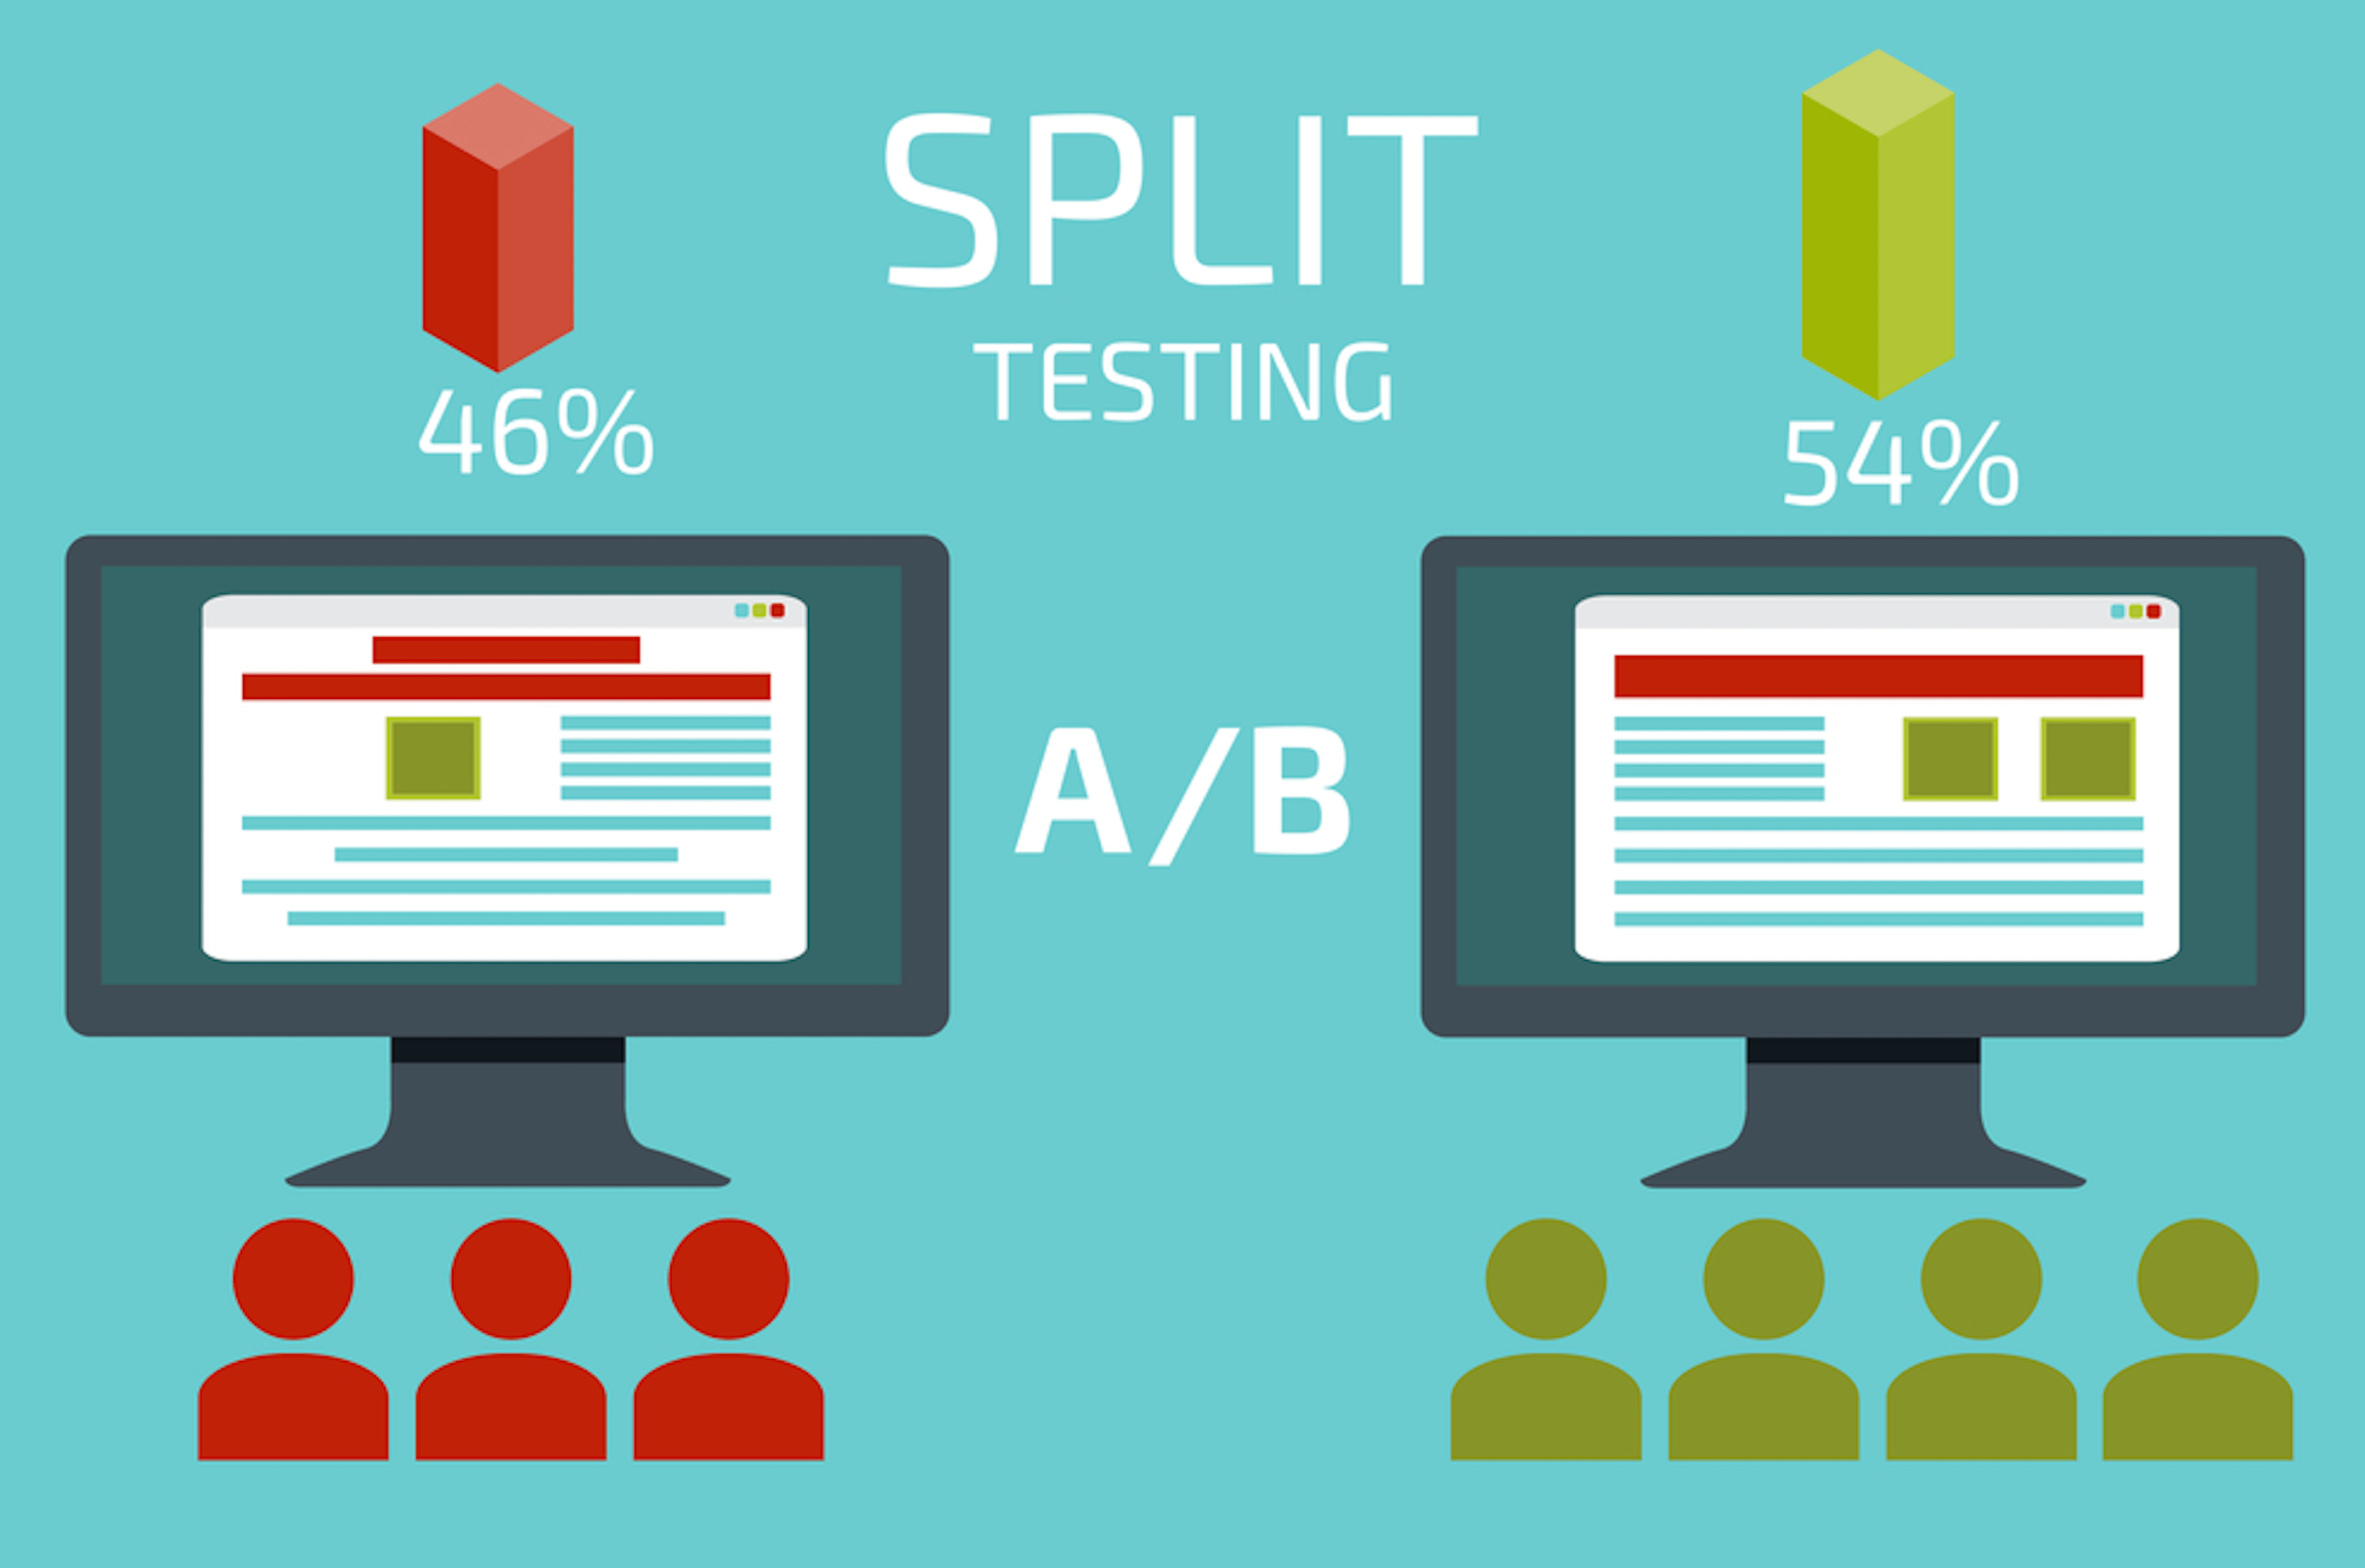

The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro
from pathlib import Path
import urllib.request
import zipfile

sns.set_theme(style="whitegrid")


In [ ]:
dataset_url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%208%20-%20Hackathon%20%26%20AB%20Testing/W8D3%20-%20AB%20Testing/AB_Test_Results.zip"
archive_path = Path("AB_Test_Results.zip")
data_path = Path("AB_Test_Results/AB_Test_Results/AB_Test_Results.csv")

if not data_path.exists():
    if not archive_path.exists():
        urllib.request.urlretrieve(dataset_url, archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall("AB_Test_Results")

df = pd.read_csv(data_path)
df.head()


Let's take a quick look at the data

In [ ]:
df.head()

In [ ]:
df.nunique()

In [ ]:
df.describe()

Let's see if there are users who have two ab test groups

In [ ]:
# taking look at the distribution of the number of unique groups for each user
double_variant_count = df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts()
double_variant_count

In [ ]:
# also look in relative terms
double_variant_count / double_variant_count.sum()

We see that there are such users and there are quite a lot of them - 24%. If you take these users into account, then the effect of changes in the experiment will be blurred. Therefore, we exclude user data from the calculation of changes in the experiment

In [ ]:
# first, let's see which users have 1 ab test group
single_variant_users = (df.groupby('USER_ID')['VARIANT_NAME'].nunique() == 1)
# and then take only these users
single_variant_users = single_variant_users[single_variant_users]

In [ ]:
# leave only records with users with the 1st ab test group
df = df[df['USER_ID'].isin(single_variant_users.index)]
# just in case, check that the number of users matches what it was before the exception
df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts().iloc[0] == double_variant_count.iloc[0]

Let's see how the data is distributed

In [ ]:
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df)

It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [ ]:
df.sort_values(by='REVENUE', ascending=False).iloc[:10]

Let's see if user 3342 had other events with a strong outlier

In [ ]:
df[df['USER_ID'] == 3342]

We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

In [ ]:
df = df[df['USER_ID'] != 3342]

In [ ]:
f, axes = plt.subplots(2, sharex=True, figsize=(5,12))
sns.boxplot(ax = axes[0], x = 'VARIANT_NAME', y = 'REVENUE', data = df)
sns.boxplot(ax = axes[1], x = 'VARIANT_NAME', y = 'REVENUE', data = df[df['REVENUE'] > 0])
plt.xticks(np.arange(2), ('control', 'variant'))

We see that most of the users have no purchases. Let's see what kind of empty purchases these are: either this is information on all users, regardless of their actions (even in the absence of visits and positive purchases), or these records are put down in case of entry without purchases and there may be other records with positive revenue.

In [ ]:
# Check if there are users who have records with zero and positive revenue.
user_revenue_range = df.groupby("USER_ID")["REVENUE"].agg(["min", "max"])
users_with_zero_and_positive = user_revenue_range[
    (user_revenue_range["min"] == 0) & (user_revenue_range["max"] > 0)
]

print(f"Users with both zero and positive revenue records: {len(users_with_zero_and_positive)}")
users_with_zero_and_positive.head()


The same user can indeed have records with both zero and positive revenue.

Let's make the assumption that the records are user visits to the service, and the experimental unit is users. Then we group the data for each user and sum the revenue for each to get one record per user

In [ ]:
df = df.groupby(by=['USER_ID', 'VARIANT_NAME']).sum().reset_index()

Let's look at the resulting distributions

In [ ]:
f, axes = plt.subplots(2, sharex=True, figsize=(5,12))
sns.boxplot(ax = axes[0], x = 'VARIANT_NAME', y = 'REVENUE', data = df)
sns.boxplot(ax = axes[1], x = 'VARIANT_NAME', y = 'REVENUE', data = df[df['REVENUE'] > 0])
plt.xticks(np.arange(2), ('control', 'variant'))

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [ ]:
# Get metrics by groups for all users.
all_stat = df.groupby(by="VARIANT_NAME").agg({
    "USER_ID": "nunique",
    "REVENUE": ["sum", "mean", "median", "count"],
})

# Create two additional metrics to see relative changes.
orders_per_user = all_stat.loc[:, ("REVENUE", "count")] / all_stat.loc[:, ("USER_ID", "nunique")]
revenue_per_user = all_stat.loc[:, ("REVENUE", "sum")] / all_stat.loc[:, ("USER_ID", "nunique")]

# Add them to the rest of the metrics in a separate group.
all_stat.loc[:, ("per_user", "orders")] = orders_per_user
all_stat.loc[:, ("per_user", "revenue")] = revenue_per_user

all_stat


The variant group has lower total revenue and lower average revenue per user than the control group. After aggregating to one row per user, the `orders per user` metric is equal to 1 for both groups, so it is not informative at this stage of the analysis.


In [ ]:
# Get metrics by groups for paying users.
paid_stat = df.loc[df["REVENUE"] > 0].groupby(by="VARIANT_NAME").agg({
    "USER_ID": "nunique",
    "REVENUE": ["sum", "mean", "median", "count"],
})

# Create two additional metrics to see relative changes.
orders_per_user = paid_stat.loc[:, ("REVENUE", "count")] / paid_stat.loc[:, ("USER_ID", "nunique")]
revenue_per_user = paid_stat.loc[:, ("REVENUE", "sum")] / paid_stat.loc[:, ("USER_ID", "nunique")]

# Add them to the rest of the metrics in a separate group.
paid_stat.loc[:, ("per_user", "orders")] = orders_per_user
paid_stat.loc[:, ("per_user", "revenue")] = revenue_per_user

paid_stat


Let's look at the distributions of all and only paying users

In [ ]:
f, axes = plt.subplots(2, figsize=(10, 8))

sns.histplot(
    data=df,
    x="REVENUE",
    hue="VARIANT_NAME",
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Distribution of revenue of all users")

sns.histplot(
    data=df[df["REVENUE"] > 0],
    x="REVENUE",
    hue="VARIANT_NAME",
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Paying user revenue distribution")
plt.subplots_adjust(hspace=0.3)


### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed, but just in case, we can confirm this formally using the Shapiro-Wilk criterion

In [ ]:
for group_name in ["control", "variant"]:
    result = shapiro(df.loc[df["VARIANT_NAME"] == group_name, "REVENUE"])
    print(f"{group_name}: statistic={result.statistic:.4f}, p-value={result.pvalue:.4g}")


The null hypothesis that revenue is normally distributed is rejected for both groups because the Shapiro-Wilk p-values are far below 0.05.


#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [ ]:
(df['REVENUE'] == 0).value_counts()

Let's first check on the data of all users

In [ ]:
mannwhitneyu(
    df.loc[df["VARIANT_NAME"] == "variant", "REVENUE"],
    df.loc[df["VARIANT_NAME"] == "control", "REVENUE"],
)


And only those who pay

In [ ]:
mannwhitneyu(
    df.loc[(df["VARIANT_NAME"] == "variant") & (df["REVENUE"] > 0), "REVENUE"],
    df.loc[(df["VARIANT_NAME"] == "control") & (df["REVENUE"] > 0), "REVENUE"],
)


#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [ ]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

Let's generate samples for all users

In [ ]:
np.random.seed(42)

control = get_bootstrap_samples(df.loc[df["VARIANT_NAME"] == "control", "REVENUE"].values, 10000)
variant = get_bootstrap_samples(df.loc[df["VARIANT_NAME"] == "variant", "REVENUE"].values, 10000)


And only for the paying users

In [ ]:
control_paid = get_bootstrap_samples(
    df.loc[(df["VARIANT_NAME"] == "control") & (df["REVENUE"] > 0), "REVENUE"].values,
    10000,
)
variant_paid = get_bootstrap_samples(
    df.loc[(df["VARIANT_NAME"] == "variant") & (df["REVENUE"] > 0), "REVENUE"].values,
    10000,
)


Let's look at the distribution of means in the ab test groups

In [ ]:
f, ax = plt.subplots()
sns.kdeplot(np.mean(control, axis=1), fill=True, label="control")
sns.kdeplot(np.mean(variant, axis=1), fill=True, label="variant")
plt.title("Sample mean distribution for all users")
plt.legend()


In [ ]:
f, ax = plt.subplots()
sns.kdeplot(np.mean(control_paid, axis=1), fill=True, label="control")
sns.kdeplot(np.mean(variant_paid, axis=1), fill=True, label="variant")
plt.title("Sample mean distribution for paying users")
plt.legend()


The bootstrap mean distributions show the control group above the variant group for both all users and paying users. However, visual overlap alone is not enough for a final decision, so we need confidence intervals for the difference in means.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization.


In [ ]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """Plot the distribution of the mean difference and return the confidence interval."""
    f, ax = plt.subplots()
    differences = variant - control
    interval = stat_intervals(differences, alpha)
    points = sns.kdeplot(differences).get_lines()[0].get_data()
    x = points[0]
    y = points[1]
    _, ymax = plt.ylim()

    plt.vlines(0, 0, ymax, label="0", color="gray")
    plt.vlines(interval[0], 0, ymax, linestyles="dashed")
    plt.vlines(interval[1], 0, ymax, linestyles="dashed")
    plt.fill_between(x, y, where=(x >= interval[1]), color="gainsboro")
    plt.fill_between(x, y, where=(x <= interval[0]), color="gainsboro")
    plt.fill_between(
        x,
        y,
        where=((x >= interval[0]) & (x <= interval[1])),
        color="red",
        label="95% confidence interval",
    )
    plt.title(
        f"Distribution of difference between means (variant - control) {title}; "
        f"{100 * (1 - alpha)}% confidence interval: {interval}"
    )
    plt.legend(prop={"size": 13})
    return interval


In [ ]:
plot_distribution_and_stat_intervals(
    np.mean(variant, axis=1), 
    np.mean(control, axis=1),
    title='all users'
)


Let's build graphs of the distribution of the difference in means and get confidence intervals.

For paying users:


In [ ]:
plot_distribution_and_stat_intervals(
    np.mean(variant_paid, axis=1), 
    np.mean(control_paid, axis=1), 
    title='paying users'
)

The 95% confidence interval for the all-user mean difference includes zero, and the 95% confidence interval for the paying-user mean difference also includes zero. Therefore, the observed decrease in average revenue for the variant group is not statistically significant at the 5% level.


### Conclusions <a name="Conclusions"/>

Before comparing the A/B test groups, the data was cleaned and reshaped:

- Users who appeared in both A/B groups were excluded, because their revenue cannot be clearly attributed to either condition.
- User `3342` was removed because it had a single extreme revenue outlier of `196.01`.
- Revenue was aggregated to one record per user, because the experimental unit is the user rather than the visit/event.

After cleaning, the control group contains `2,389` users and the variant group contains `2,393` users. The control group has higher total revenue (`274.55` vs. `179.32`) and higher average revenue per user (`0.115` vs. `0.075`). Among paying users, the control group also has a higher average revenue (`5.18` vs. `4.27`).

The revenue distribution is highly non-normal, which is confirmed by the Shapiro-Wilk test. The Mann-Whitney tests are not significant for all users (`p ≈ 0.248`) or paying users (`p ≈ 0.531`). Bootstrap confidence intervals for the difference in mean revenue also include zero for both all users and paying users.

Overall, there is no statistically significant evidence that the variant increased revenue. In fact, the observed metrics are lower for the variant group, so based on this data the new version should not be launched as a revenue-improving change without further testing.
